WITHIN-PARTICIPANT RSA, two different versions

hypothesis: Hippocampus patterns for moral events are shaped by a common latent structure (e.g., moral schema). Non-moral events are more heterogeneous — each event may have different patterns because there’s no shared “category-level” representation underlying it, over and above the shared narrative that all sentences have in common. That means that two moral events, moral-event1 and moral-event2, will have a similar spatial pattern pearson correlation score as moral-event1 to moral-event3, because despite moral-event2 and moral-event3 being different events, they have the same underlying moral schema. 

version1: odd-even event split, with computing an average spatial pattern across the hippocampal voxels of the various TRs within a given event/sentence. Testing category-level representational geometry, with the logic of treating all sentences that are moral as instances of the same category (sort of similar logic as perception RSA studies do with picture of birdA, birdB etc in visual cortex region, somewhat different though because they will show the same pictures multiple times, counterbalanced across runs to avoid temporal autocorrelation). 

version2: within-event split: if morality influences event representation in the hippocampus in the same way all the time, it will lead to more stable event-representations within-event compared to non-moral sentences.

In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_moral_nonmoral"

In [3]:
# ------------------------
# Load 
# ------------------------

whichROI = "hippocampus" # hippocampus

whichStory = "tunnel"  # tunnel, 21styear, shapessocial, prettymouthaffair,prettymouthparanoia

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

# make sure foundation scores for pretty mouth are found
if whichStory == 'prettymouthaffair':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichStory == 'prettymouthparanoia':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
else:
    print('use foundation scores of WhichStory')
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")



use foundation scores of WhichStory
tunnel
hippocampus


In [4]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [5]:
# split into the moral vs non moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]

foundationScoresSelect_zero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] == 0]


## split in odd vs even events (so, separate events and compute mean pattern across TRs within an event to use)

Running RSA for moral sentences...
Running RSA for non-moral sentences...
Paired t-test: t(20) = 5.419, p = 0.0000
Mean RSA moral: 0.18804087488743254 Mean RSA non-moral: 0.14991557346642953


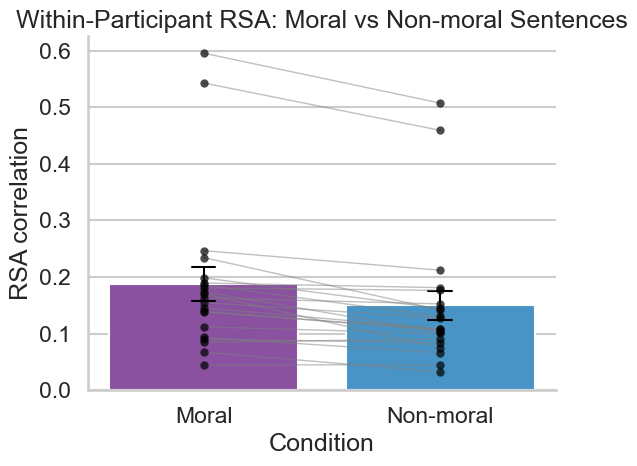

In [6]:
# ================================================================
def run_within_participant_rsa(data_array, events):
    """
    data_array : np.ndarray, shape (voxels x volumes x participants)
    events     : DataFrame with columns ['startTR', 'endTR']
    Returns    : np.array of RSA correlations per participant
    """
    # Sort and clean events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    event_ids = events.index.values

    # Odd/even split to minimize temporal autocorrelation
    split1_ids = event_ids[::2]
    split2_ids = event_ids[1::2]

    # Equalize length
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    results = []

    for p in range(n_participants):
        data = data_array[:, :, p].copy()
        data = zscore(data, axis=1, ddof=1)  # normalize voxelwise over time

        split1_patterns, split2_patterns = [], []

        for eid in split1_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split1_patterns.append(pattern)

        for eid in split2_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split2_patterns.append(pattern)

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        # Compute representational dissimilarity matrices (1 - Pearson correlation)
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))

        # Vectorize upper triangles and correlate (Spearman)
        iu = np.triu_indices(n_events, k=1)
        rsa_corr, _ = spearmanr(rdm1[iu], rdm2[iu])
        results.append(rsa_corr)

    return np.array(results)


# ================================================================
# Run RSA separately for moral and non-moral events
# ================================================================
print("Running RSA for moral sentences...")
rsa_moral_left  = run_within_participant_rsa(left,  foundationScoresSelect_nonzero)
rsa_moral_right = run_within_participant_rsa(right, foundationScoresSelect_nonzero)

print("Running RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_participant_rsa(left,  foundationScoresSelect_zero)
rsa_nonmoral_right = run_within_participant_rsa(right, foundationScoresSelect_zero)

# ================================================================
# Average across hemispheres and compute difference
# ================================================================
rsa_moral_mean    = (rsa_moral_left + rsa_moral_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2
rsa_diff          = rsa_moral_mean - rsa_nonmoral_mean

# ================================================================
# Combine into one DataFrame
# ================================================================
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_moral_mean)),
    'rsa_moral_left': rsa_moral_left,
    'rsa_moral_right': rsa_moral_right,
    'rsa_moral_mean': rsa_moral_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
    'rsa_diff': rsa_diff
})

# ================================================================
# === Group stats: paired t-test ===
# ================================================================
diffs = rsa_df['rsa_moral_mean'] - rsa_df['rsa_nonmoral_mean']
t_stat, p_val = ttest_rel(rsa_df['rsa_moral_mean'], rsa_df['rsa_nonmoral_mean'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean RSA moral:", rsa_df['rsa_moral_mean'].mean(), 
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

plt.figure(figsize=(6, 5))
sns.set(style='whitegrid', context='talk')

# ================================================================
# Prepare for plotting
# ================================================================
plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_moral_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_moral_mean': 'Moral',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

# Overlay participant dots + connecting lines
sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.7
)

# Connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0, 1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-Participant RSA: Moral vs Non-moral Sentences')
ax.set_ylabel('RSA correlation')
sns.despine()
plt.tight_layout()
plt.show()

## split within event to have odd event split within event instead of across event

Running within-event split RSA for moral sentences...
Running within-event split RSA for non-moral sentences...
Paired t-test: t(20) = 2.253, p = 0.0356
Mean RSA moral: 0.21414715961681574 Mean RSA non-moral: 0.2000114610853637


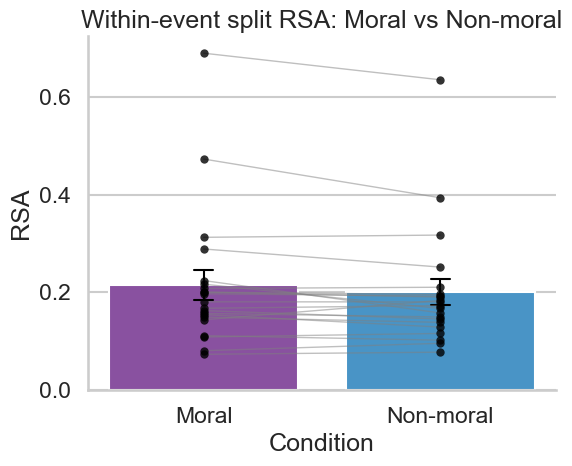

In [7]:

# === compute per-event split patterns (odd/even TRs within event) ===
def event_split_patterns_for_events(events):
    """
    Given events DataFrame with integer 'startTR' and 'endTR', produce
    for each event the indices of TRs for split A and split B (odd/even within event).
    Returns:
      valid_event_idx: list of event indices that have at least one TR in each split
      splitA_tr_indices: list of lists (TR indices for split A per valid event)
      splitB_tr_indices: list of lists (TR indices for split B per valid event)
    """
    valid_event_idx = []
    splitA_tr_indices = []
    splitB_tr_indices = []
    
    for i, ev in events.iterrows():
        s = int(ev['startTR'])
        e = int(ev['endTR'])
        # full list of TR indices for this event
        trs = np.arange(s, e + 1)
        if len(trs) == 0:
            continue
        # odd/even within the event (relative indexing)
        # choose trs with relative index %2 == 0 vs %2 == 1
        rel_idx = np.arange(len(trs))
        a_trs = trs[rel_idx % 2 == 0]
        b_trs = trs[rel_idx % 2 == 1]
        # require at least one TR in each split
        if len(a_trs) >= 1 and len(b_trs) >= 1:
            valid_event_idx.append(i)
            splitA_tr_indices.append(a_trs)
            splitB_tr_indices.append(b_trs)
    return valid_event_idx, splitA_tr_indices, splitB_tr_indices

# === RSA function using within-event split ===
def run_within_event_rsa(data_array, events):
    """
    data_array : np.ndarray with shape (voxels, n_volumes, n_participants)
    events     : DataFrame with 'startTR' and 'endTR' (integers)
    Returns    : np.array of RSA correlations per participant (hemisphere)
    """
    # Clean & ensure integer TRs
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR']   = events['endTR'].astype(int)
    
    # Build split TR lists per event, dropping events that don't have at least one TR in both splits
    valid_event_idx, splitA_trs_list, splitB_trs_list = event_split_patterns_for_events(events)
    n_events = len(valid_event_idx)
    if n_events < 2:
        raise ValueError("Not enough valid events after within-event splitting.")
    
    n_participants = data_array.shape[2]
    rsa_results = np.full(n_participants, np.nan)
    
    for p in range(n_participants):
        # voxel x time
        data = data_array[:, :, p].copy()
        # normalize voxel timecourses to be comparable (zscore across time per voxel)
        data = zscore(data, axis=1, ddof=1)
        
        # build per-event pattern estimates for split A and split B
        patternsA = []
        patternsB = []
        for a_trs, b_trs in zip(splitA_trs_list, splitB_trs_list):
            # mean over the specified TRs (axis=1 collapsed)
            patA = np.mean(data[:, a_trs], axis=1)
            patB = np.mean(data[:, b_trs], axis=1)
            patternsA.append(patA)
            patternsB.append(patB)
        
        # stack to voxels x events
        patternsA = np.column_stack(patternsA)  # voxels x n_events
        patternsB = np.column_stack(patternsB)
        
        # compute RDMs
        rdmA = squareform(pdist(patternsA.T, metric='correlation'))
        rdmB = squareform(pdist(patternsB.T, metric='correlation'))
        
        # vectorize upper triangle
        iu = np.triu_indices(n_events, k=1)
        vecA = rdmA[iu]
        vecB = rdmB[iu]
        
        # Spearman between RDMs: assesses rank-order consistency across pairwise relations
        rho, _ = spearmanr(vecA, vecB)
        rsa_results[p] = rho
    
    return rsa_results

# === Run for moral and non-moral, both hemispheres ===
print("Running within-event split RSA for moral sentences...")
rsa_moral_left  = run_within_event_rsa(left,  foundationScoresSelect_nonzero)
rsa_moral_right = run_within_event_rsa(right, foundationScoresSelect_nonzero)

print("Running within-event split RSA for non-moral sentences...")
rsa_nonmoral_left  = run_within_event_rsa(left,  foundationScoresSelect_zero)
rsa_nonmoral_right = run_within_event_rsa(right, foundationScoresSelect_zero)

# average hemispheres
rsa_moral_mean    = (rsa_moral_left + rsa_moral_right) / 2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right) / 2
rsa_diff = rsa_moral_mean - rsa_nonmoral_mean

# assemble dataframe
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_moral_mean)),
    'rsa_moral_left': rsa_moral_left,
    'rsa_moral_right': rsa_moral_right,
    'rsa_moral_mean': rsa_moral_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
    'rsa_diff': rsa_diff
})

# === Group stats: paired t-test ===
diffs = rsa_df['rsa_moral_mean'] - rsa_df['rsa_nonmoral_mean']
t_stat, p_val = ttest_rel(rsa_df['rsa_moral_mean'], rsa_df['rsa_nonmoral_mean'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean RSA moral:", rsa_df['rsa_moral_mean'].mean(), 
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

# === Plot ===
plt.figure(figsize=(6,5))
sns.set(style='whitegrid', context='talk')

plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_moral_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_moral_mean': 'Moral',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.08,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.8
)

# connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0,1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-event split RSA: Moral vs Non-moral')
ax.set_ylabel('RSA')
sns.despine()
plt.tight_layout()
plt.show()


## univariate control moral vs non-moral means

In [8]:
# average across all voxels in the mask
left_mean = left.mean(axis=0)
print("check if averaging correctly, shape of output left: ", left_mean.shape)

right_mean = right.mean(axis=0)
print("check if averaging correctly, shape of output right: ", right_mean.shape)

#compute mean across hemispheres
overallMean = (left_mean + right_mean) / 2

# determine number of subjects
n_subjects = overallMean.shape[1]

# pre-create the necessary columns
for s in range(n_subjects):
    foundationScoresSelect[f"subj{s+1}"] = np.nan

for index, row in foundationScoresSelect.iterrows():

    valueStart = int(row["startTR"])
    valueEnd = int(row["endTR"])

    for currSubj in range(n_subjects):

        # left 
        col_name = f"subj{currSubj+1}"
        foundationScoresSelect.loc[index, col_name] = overallMean[valueStart:valueEnd+1, currSubj].mean()

check if averaging correctly, shape of output left:  (1040, 21)
check if averaging correctly, shape of output right:  (1040, 21)


In [9]:
moralSentences = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]
nonmoralSentences = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] == 0]

moralSentences = moralSentences.drop(columns=['MAC_a_moral_nonmoral','start', 'end', 'startTR', 'endTR'])
nonmoralSentences = nonmoralSentences.drop(columns=['MAC_a_moral_nonmoral','start', 'end', 'startTR', 'endTR'])

means_univariate = pd.DataFrame({
    'participant': range(0,n_subjects),
    'moral': moralSentences.mean(),
    'non-moral': nonmoralSentences.mean()
})

Paired t-test: t(20) = -0.839, p = 0.4115
Mean moral: -0.007372531427516175 Mean non-moral: -0.005690965333171335


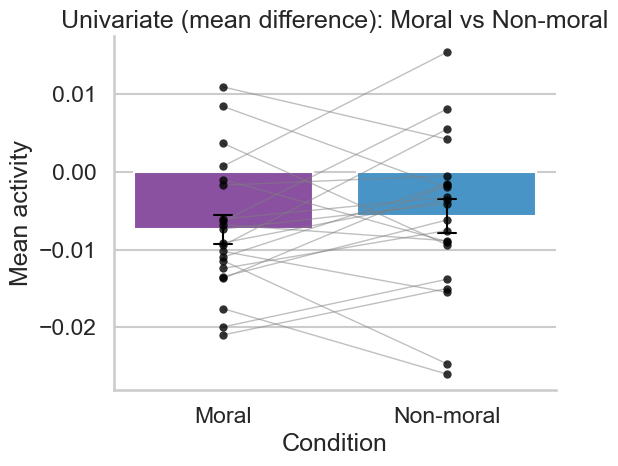

In [10]:

# === Group stats: paired t-test ===
diffs = means_univariate['moral'] - means_univariate['non-moral']
t_stat, p_val = ttest_rel(means_univariate['moral'], means_univariate['non-moral'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean moral:", means_univariate['moral'].mean(), 
      "Mean non-moral:", means_univariate['non-moral'].mean())


# === Prepare for plotting ===
plot_df = pd.melt(
    means_univariate,
    id_vars=['participant'],
    value_vars=['moral', 'non-moral'],
    var_name='Condition',
    value_name='univariate'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'moral': 'Moral',
    'non-moral': 'Non-moral'
})

# === Plot ===
plt.figure(figsize=(6,5))
sns.set(style='whitegrid', context='talk')

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='univariate', hue='Condition', legend=False,
    errorbar='se', capsize=0.08,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

sns.stripplot(
    data=plot_df,
    x='Condition', y='univariate',
    color='black', size=6, jitter=False, alpha=0.8
)

# Connect participant dots
for pid in means_univariate['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'univariate'].values
    plt.plot([0,1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Univariate (mean difference): Moral vs Non-moral')
ax.set_ylabel('Mean activity')
sns.despine()
plt.tight_layout()
plt.show()


# RSA pipeline illustration


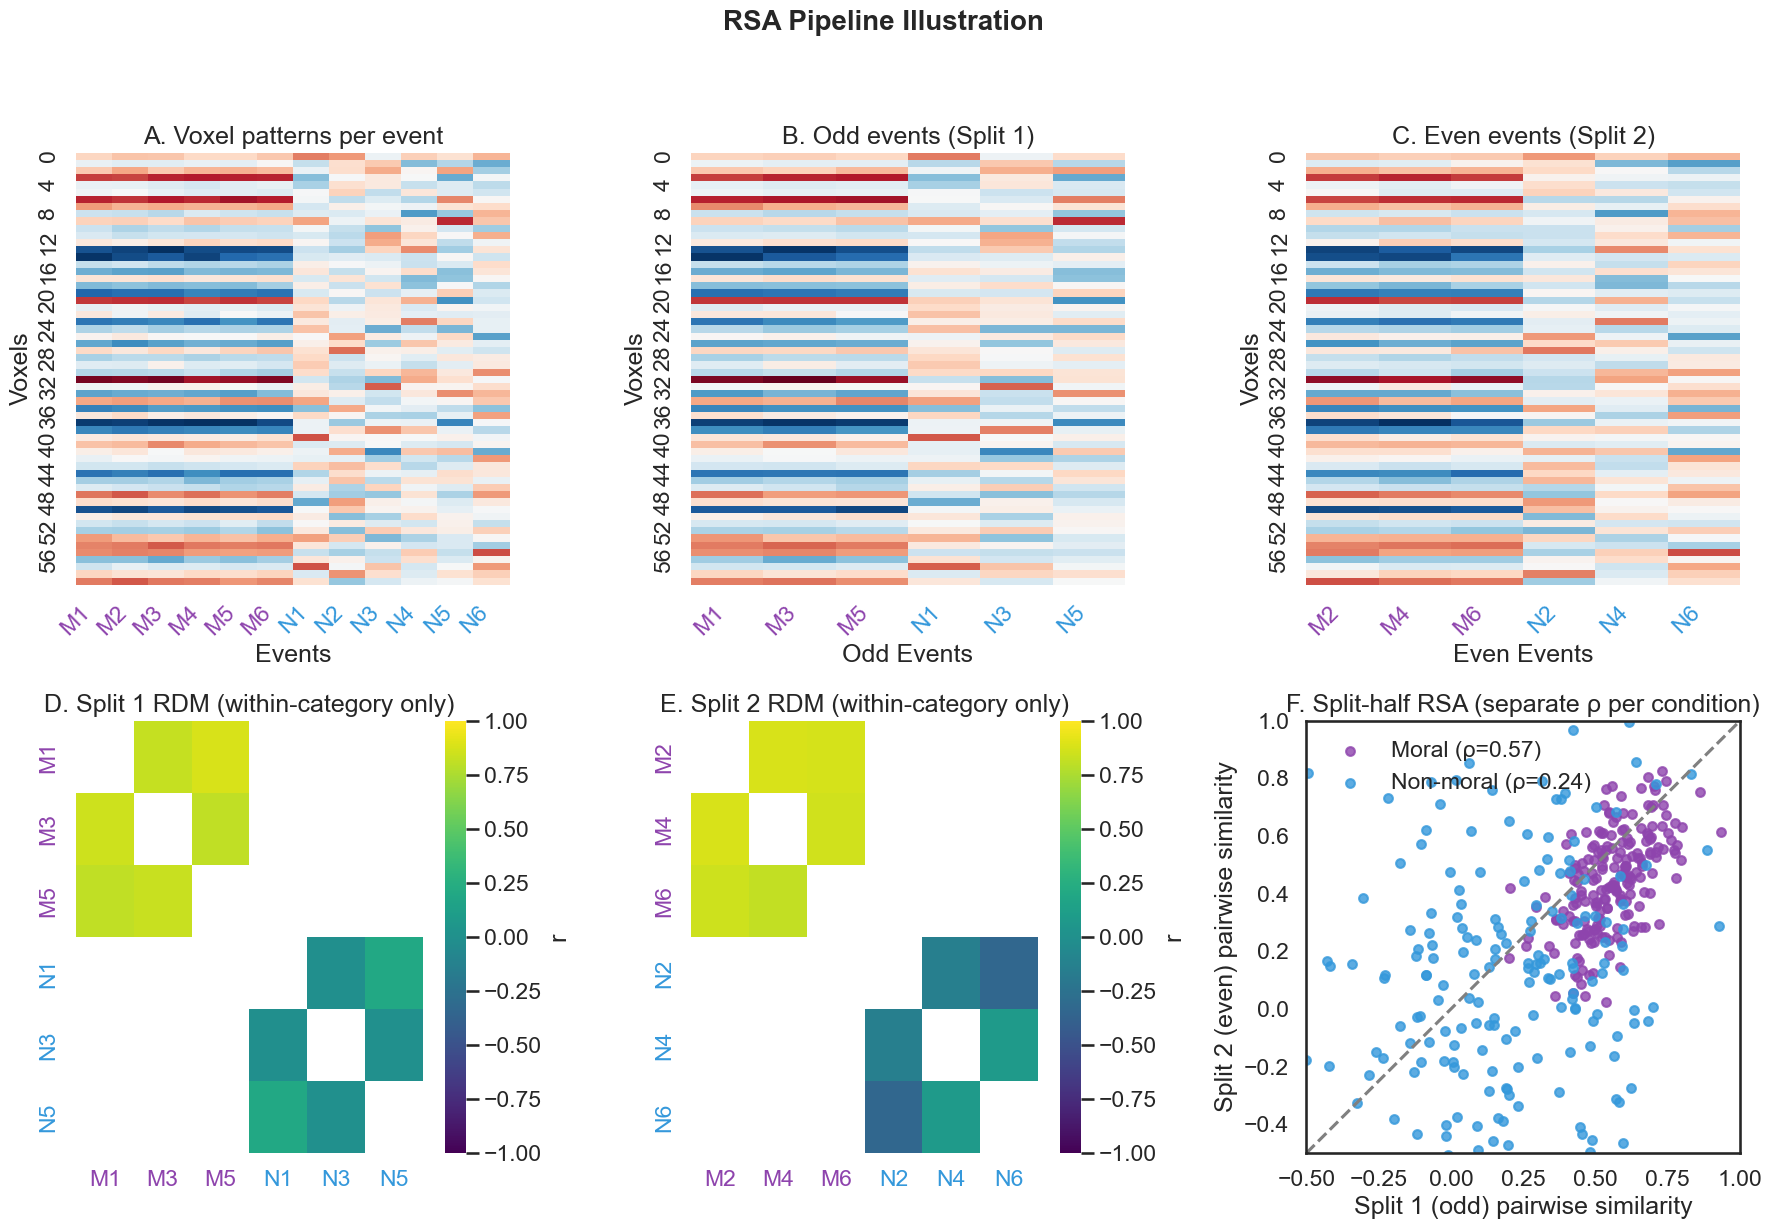

In [11]:

sns.set(style='white', context='talk')

# ------------------------------------------------------------
# 1. Simulate hippocampal voxel data
# ------------------------------------------------------------
np.random.seed(42)
voxels = 60
n_events = 12
n_moral = 6  # first 6 = moral, last 6 = non-moral

latent_moral = np.random.randn(voxels) * 2
patterns_moral = np.array([
    latent_moral + np.random.randn(voxels)*0.2  # small noise = high corr
    for _ in range(n_moral)
]).T

# Non-moral have less structure (lower correlations)
patterns_nonmoral = np.random.randn(voxels, n_events - n_moral)

# Combine moral + non-moral
patterns = np.concatenate([patterns_moral, patterns_nonmoral], axis=1)
labels = [f"M{i+1}" for i in range(n_moral)] + [f"N{i+1}" for i in range(n_events - n_moral)]

# ------------------------------------------------------------
# 2. Odd/even split
# ------------------------------------------------------------
odd_idx = np.arange(0, n_events, 2)   # 0,2,4,6,8,10
even_idx = np.arange(1, n_events, 2)  # 1,3,5,7,9,11

patterns_odd = patterns[:, odd_idx] + np.random.randn(voxels, len(odd_idx))*0.1
patterns_even = patterns[:, even_idx] + np.random.randn(voxels, len(even_idx))*0.1

labels_odd = [labels[i] for i in odd_idx]
labels_even = [labels[i] for i in even_idx]

# ------------------------------------------------------------
# 3. Compute RDMs (Pearson)
# ------------------------------------------------------------
rdm_odd = np.corrcoef(patterns_odd.T)
rdm_even = np.corrcoef(patterns_even.T)

# Force within-moral correlations to ~0.85
for i, li in enumerate(labels_odd):
    for j, lj in enumerate(labels_odd):
        if li.startswith('M') and lj.startswith('M') and i != j:
            rdm_odd[i, j] = 0.8 + np.random.rand() * 0.1
for i, li in enumerate(labels_even):
    for j, lj in enumerate(labels_even):
        if li.startswith('M') and lj.startswith('M') and i != j:
            rdm_even[i, j] = 0.8 + np.random.rand() * 0.1

# ------------------------------------------------------------
# 4. Mask diagonals and cross-category cells
# ------------------------------------------------------------
mask_odd = np.zeros_like(rdm_odd, dtype=bool)
mask_even = np.zeros_like(rdm_even, dtype=bool)
np.fill_diagonal(mask_odd, True)
np.fill_diagonal(mask_even, True)

for i, li in enumerate(labels_odd):
    for j, lj in enumerate(labels_odd):
        if (li.startswith('M') and lj.startswith('N')) or (li.startswith('N') and lj.startswith('M')):
            mask_odd[i, j] = True
for i, li in enumerate(labels_even):
    for j, lj in enumerate(labels_even):
        if (li.startswith('M') and lj.startswith('N')) or (li.startswith('N') and lj.startswith('M')):
            mask_even[i, j] = True

rdm_odd_masked = rdm_odd.copy()
rdm_even_masked = rdm_even.copy()
rdm_odd_masked[mask_odd] = np.nan
rdm_even_masked[mask_even] = np.nan

# RSA correlation (split-half Spearman)
iu = np.triu_indices_from(rdm_odd, k=1)
vec_odd = rdm_odd[iu]
vec_even = rdm_even[iu]
mask_valid = ~np.isnan(vec_odd) & ~np.isnan(vec_even)
rsa_corr, _ = spearmanr(vec_odd[mask_valid], vec_even[mask_valid])

# ------------------------------------------------------------
# 5. Plot: composite figure with 7 panels
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

fig.suptitle("RSA Pipeline Illustration", fontsize=20, fontweight='bold', y=1.03)

# A: all voxel patterns
sns.heatmap(patterns, cmap='RdBu_r', center=0, ax=axes[0], cbar=False)
axes[0].set_title("A. Voxel patterns per event")
axes[0].set_xlabel("Events")
axes[0].set_ylabel("Voxels")
axes[0].set_xticks(np.arange(n_events)+0.5)
axes[0].set_xticklabels(labels, rotation=45, ha='right')

# B: odd split
sns.heatmap(patterns_odd, cmap='RdBu_r', center=0, ax=axes[1], cbar=False)
axes[1].set_title("B. Odd events (Split 1)")
axes[1].set_xlabel("Odd Events")
axes[1].set_ylabel("Voxels")
axes[1].set_xticks(np.arange(len(odd_idx))+0.5)
axes[1].set_xticklabels(labels_odd, rotation=45, ha='right')

# C: even split
sns.heatmap(patterns_even, cmap='RdBu_r', center=0, ax=axes[2], cbar=False)
axes[2].set_title("C. Even events (Split 2)")
axes[2].set_xlabel("Even Events")
axes[2].set_ylabel("Voxels")
axes[2].set_xticks(np.arange(len(even_idx))+0.5)
axes[2].set_xticklabels(labels_even, rotation=45, ha='right')

# D: Split 1 RDM (within-category)
sns.heatmap(rdm_odd_masked, cmap='viridis', vmin=-1, vmax=1,
            xticklabels=labels_odd, yticklabels=labels_odd, ax=axes[3],
            mask=np.isnan(rdm_odd_masked), cbar_kws={'label':'r'})
axes[3].set_title("D. Split 1 RDM (within-category only)")

# E: Split 2 RDM (within-category)
sns.heatmap(rdm_even_masked, cmap='viridis', vmin=-1, vmax=1,
            xticklabels=labels_even, yticklabels=labels_even, ax=axes[4],
            mask=np.isnan(rdm_even_masked), cbar_kws={'label':'r'})
axes[4].set_title("E. Split 2 RDM (within-category only)")

# F: Split-half scatter (moral vs non-moral), with more controlled reliabilities
n_pairs = 200  # more pairs = more stable rho estimates

# Moral pairs: moderately reliable, coherent geometry
odd_moral = np.random.normal(0.55, 0.12, n_pairs)
# even = odd + small correlated noise
even_moral = odd_moral * 0.8 + np.random.normal(0, 0.15, n_pairs)

# Non-moral pairs: lower reliability, high noise and weak linear relation
odd_nonmoral = np.random.normal(0.2, 0.35, n_pairs)
even_nonmoral = odd_nonmoral * 0.3 + np.random.normal(0, 0.4, n_pairs)

# Compute separate Spearman correlations (split-half RSA)
rho_moral, _ = spearmanr(odd_moral, even_moral)
rho_nonmoral, _ = spearmanr(odd_nonmoral, even_nonmoral)

# Scatter plot
axes[5].scatter(
    odd_moral, even_moral, color='#8E44AD', alpha=0.8, s=40,
    label=f'Moral (ρ={rho_moral:.2f})'
)
axes[5].scatter(
    odd_nonmoral, even_nonmoral, color='#3498DB', alpha=0.8, s=40,
    label=f'Non-moral (ρ={rho_nonmoral:.2f})'
)
axes[5].plot([-0.5, 1], [-0.5, 1], color='gray', linestyle='--')
axes[5].set_xlim(-0.5, 1)
axes[5].set_ylim(-0.5, 1)
axes[5].set_xlabel("Split 1 (odd) pairwise similarity")
axes[5].set_ylabel("Split 2 (even) pairwise similarity")
axes[5].set_title("F. Split-half RSA (separate ρ per condition)")
axes[5].legend(frameon=False, loc='upper left')

# changes axis text colors labels:
# Panel A
for i, tick in enumerate(axes[0].get_xticklabels()):
    if i < 6:
        tick.set_color('#8E44AD')  # moral
    else:
        tick.set_color('#3498DB')  # non-moral

# Panel B
for i, tick in enumerate(axes[1].get_xticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')

for i, tick in enumerate(axes[2].get_xticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')

for i, tick in enumerate(axes[3].get_xticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')

for i, tick in enumerate(axes[4].get_xticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')

for i, tick in enumerate(axes[3].get_yticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')

for i, tick in enumerate(axes[4].get_yticklabels()):
    if i < 3:
        tick.set_color('#8E44AD')
    else:
        tick.set_color('#3498DB')



plt.tight_layout()
plt.show()


# sanity check: save the rdm's for the across-sentence RSA

Running RSA for moral sentences...
Running RSA for non-moral sentences...


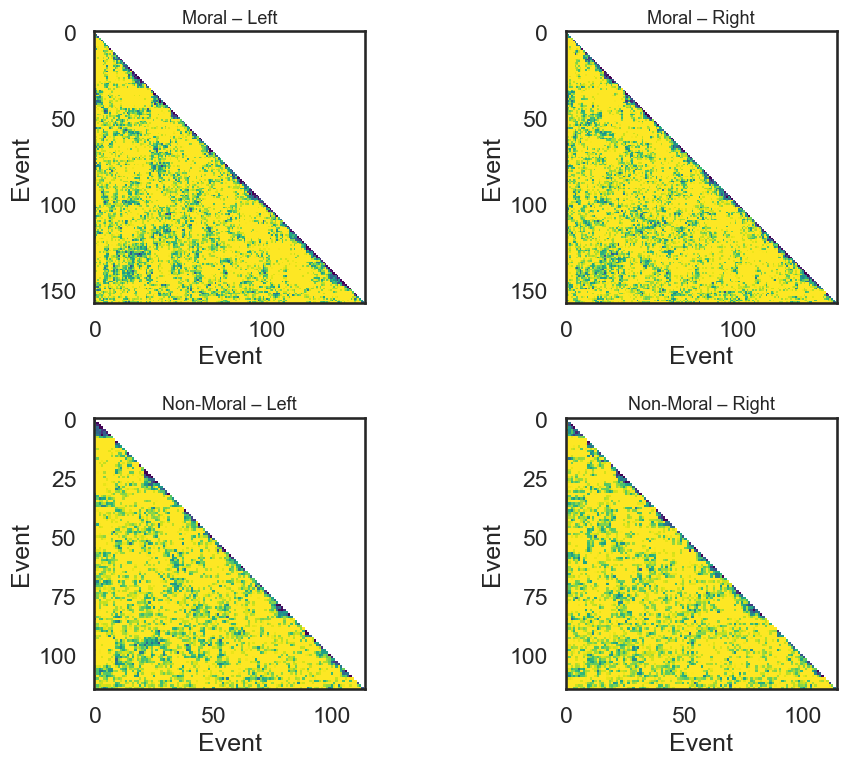

In [12]:
def save_rdms_rsa(data_array, events):

    # Sort and clean events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    event_ids = events.index.values

    # Odd/even split to minimize temporal autocorrelation
    split1_ids = event_ids[::2]
    split2_ids = event_ids[1::2]

    # Equalize length
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    rsa_results = []
    avg_rdms = np.zeros((n_events, n_events, n_participants))

    for p in range(n_participants):
        data = data_array[:, :, p].copy()
        data = zscore(data, axis=1, ddof=1)  # normalize voxelwise over time

        split1_patterns, split2_patterns = [], []

        for eid in split1_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split1_patterns.append(pattern)

        for eid in split2_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr = int(ev['endTR'])
            pattern = np.mean(data[:, start_tr:end_tr + 1], axis=1)
            split2_patterns.append(pattern)

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        # Compute representational dissimilarity matrices (1 - Pearson correlation)
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))

        # Average RDM across both halves
        avg_rdm = (rdm1 + rdm2) / 2
        avg_rdms[:, :, p] = avg_rdm

    return avg_rdms

# ================================================================
# Run RSA separately for moral and non-moral events
# ================================================================
print("Running RSA for moral sentences...")
rdm_moral_left  = save_rdms_rsa(left,  foundationScoresSelect_nonzero)
rdm_moral_right = save_rdms_rsa(right, foundationScoresSelect_nonzero)

print("Running RSA for non-moral sentences...")
rdm_nonmoral_left  = save_rdms_rsa(left,  foundationScoresSelect_zero)
rdm_nonmoral_right = save_rdms_rsa(right, foundationScoresSelect_zero)

rdm_moral_left_mean = rdm_moral_left.mean(axis=2)
rdm_moral_right_mean = rdm_moral_right.mean(axis=2)
rdm_nonmoral_left_mean = rdm_nonmoral_left.mean(axis=2)
rdm_nonmoral_right_mean = rdm_nonmoral_right.mean(axis=2)

rdm_list = [
    rdm_moral_left_mean,
    rdm_moral_right_mean,
    rdm_nonmoral_left_mean,
    rdm_nonmoral_right_mean
]
titles = [
    "Moral – Left",
    "Moral – Right",
    "Non-Moral – Left",
    "Non-Moral – Right"
]



# Mask upper triangle *and* diagonal
masked_rdms = []
for rdm in rdm_list:
    mask = np.triu(np.ones_like(rdm, dtype=bool))  # diagonal included
    masked_rdm = np.ma.masked_where(mask, rdm)
    masked_rdms.append(masked_rdm)

# Compute shared color limits
vmin = min(np.min(rdm) for rdm in rdm_list)
vmax = max(np.max(rdm) for rdm in rdm_list)

# --- manual fixed range ---
vmin, vmax = 0.9, 1.0

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, rdm, title in zip(axes.flat, masked_rdms, titles):
    im = ax.imshow(rdm, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Event")
    ax.set_ylabel("Event")
    ax.set_aspect('equal', adjustable='box')

# Shared colorbar
#cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.04)
#cbar.set_label("Dissimilarity (1 - r)", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# plot timeline to test if z scoring worked well to remove signal drift

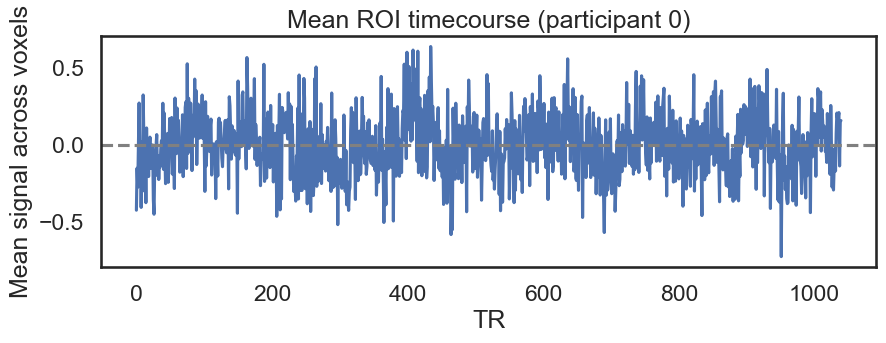

In [13]:
p = 0  # change to 1,2,... as needed, or loop over participants

mean_timecourse = np.mean(left[:, :, p], axis=0)  # mean over voxels -> length n_volumes
plt.figure(figsize=(10,3))
plt.plot(mean_timecourse)
plt.title(f"Mean ROI timecourse (participant {p})")
plt.xlabel("TR")
plt.ylabel("Mean signal across voxels")
plt.axhline(np.mean(mean_timecourse), color='gray', linestyle='--')
plt.show()


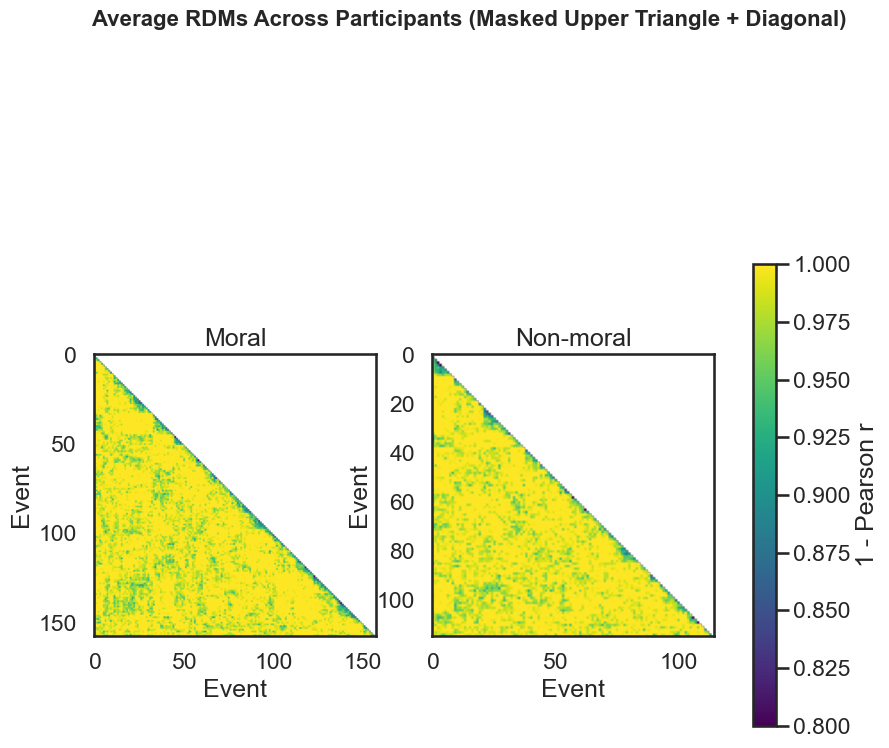

In [14]:
def average_rdm(data_array, events, demean=False):
    """
    Compute the average RDM (1-Pearson) across participants.
    """
    events = events.dropna(subset=['startTR','endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR']   = events['endTR'].astype(int)
    event_ids = events.index.values

    split1_ids = event_ids[::2]
    split2_ids = event_ids[1::2]
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    rdms = []

    for p in range(n_participants):
        data = zscore(data_array[:, :, p], axis=1, ddof=1)

        split1_patterns, split2_patterns = [], []
        for eid in split1_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr   = int(ev['endTR'])
            split1_patterns.append(np.mean(data[:, start_tr:end_tr+1], axis=1))
        for eid in split2_ids:
            ev = events.iloc[eid]
            start_tr = int(ev['startTR'])
            end_tr   = int(ev['endTR'])
            split2_patterns.append(np.mean(data[:, start_tr:end_tr+1], axis=1))

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        if demean:
            split1_patterns -= np.mean(split1_patterns, axis=1, keepdims=True)
            split2_patterns -= np.mean(split2_patterns, axis=1, keepdims=True)

        # Average the RDMs from split1 and split2
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))
        rdms.append((rdm1 + rdm2)/2)

    return np.mean(rdms, axis=0)

# ----------------------------------------------------------
# Compute average RDMs
# ----------------------------------------------------------
rdm_moral_raw     = average_rdm(left, foundationScoresSelect_nonzero, demean=False)
rdm_nonmoral_raw  = average_rdm(left, foundationScoresSelect_zero, demean=False)

# ----------------------------------------------------------
# Mask upper triangle + diagonal
# ----------------------------------------------------------
def mask_upper_diag(rdm):
    rdm_masked = rdm.copy()
    iu = np.triu_indices_from(rdm_masked)
    rdm_masked[iu] = np.nan
    return rdm_masked

rdm_moral_raw_masked    = mask_upper_diag(rdm_moral_raw)
rdm_nonmoral_raw_masked = mask_upper_diag(rdm_nonmoral_raw)

# ----------------------------------------------------------
# Plotting
# ----------------------------------------------------------
fig, axes = plt.subplots(1,2, figsize=(10,10))

im0 = axes[0].imshow(rdm_moral_raw_masked, vmin=0.8, vmax=1, cmap='viridis')
axes[0].set_title("Moral")
im1 = axes[1].imshow(rdm_nonmoral_raw_masked, vmin=0.8, vmax=1, cmap='viridis')
axes[1].set_title("Non-moral")
for ax in axes.flatten():
    ax.set_xlabel("Event")
    ax.set_ylabel("Event")

fig.colorbar(im0, ax=axes.ravel().tolist(), shrink=0.6, label="1 - Pearson r")
plt.suptitle("Average RDMs Across Participants (Masked Upper Triangle + Diagonal)", fontsize=16, fontweight='bold')
#plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# now run RSA across segments instead, defined segments based on moral-nonmoral ratio (blocks of zeros vs blocks of non-zeros)

In [15]:
# Make sure dataframe is sorted by time (TR)
foundationScoresSelect = foundationScoresSelect.sort_values('startTR').reset_index(drop=True)

# Create a column that marks where the moral/non-moral value changes
foundationScoresSelect['label'] = (foundationScoresSelect['MAC_a_moral_nonmoral'] > 0).astype(int)

# Find boundaries of consecutive segments
foundationScoresSelect['segment_change'] = foundationScoresSelect['label'].diff().fillna(0).astype(bool)

# Assign a unique segment ID to each consecutive block
foundationScoresSelect['segment_id'] = foundationScoresSelect['segment_change'].cumsum()

# Aggregate to define startTR and endTR for each segment
segments = foundationScoresSelect.groupby('segment_id').agg(
    startTR=('startTR', 'first'),
    endTR=('endTR', 'last'),
    label=('label', 'first')
).reset_index(drop=True)

# split into moral vs non-moral dataframes
segments_moral = segments[segments['label'] == 1].reset_index(drop=True)
segments_nonmoral = segments[segments['label'] == 0].reset_index(drop=True)

print("Segments dataframe:")
print(segments.head())


Segments dataframe:
   startTR  endTR  label
0        3      6      1
1        6     15      0
2       18     25      1
3       25     29      0
4       29     30      1


In [16]:
def run_within_participant_rsa_segments(data_array, segments_df, demean=False):
    """
    Split-half RSA using segment-based events (consecutive moral/non-moral sentences combined).

    Parameters
    ----------
    data_array : np.ndarray (voxels x volumes x participants)
    segments_df : pd.DataFrame with columns ['startTR', 'endTR']
    demean : bool
        If True, subtract voxel-wise mean across events in each split

    Returns
    -------
    results : np.ndarray of Spearman rho per participant
    """
    # Clean segments
    segments_df = segments_df.dropna(subset=['startTR','endTR']).sort_values('startTR').reset_index(drop=True)
    segments_df['startTR'] = segments_df['startTR'].astype(int)
    segments_df['endTR']   = segments_df['endTR'].astype(int)
    segment_ids = segments_df.index.values

    # Odd/even split to reduce temporal autocorrelation
    split1_ids = segment_ids[::2]
    split2_ids = segment_ids[1::2]
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    results = []

    for p in range(n_participants):
        data = zscore(data_array[:, :, p], axis=1, ddof=1)

        split1_patterns, split2_patterns = [], []
        for eid in split1_ids:
            seg = segments_df.iloc[eid]
            start_tr = int(seg['startTR'])
            end_tr   = int(seg['endTR'])
            split1_patterns.append(np.mean(data[:, start_tr:end_tr+1], axis=1))

        for eid in split2_ids:
            seg = segments_df.iloc[eid]
            start_tr = int(seg['startTR'])
            end_tr   = int(seg['endTR'])
            split2_patterns.append(np.mean(data[:, start_tr:end_tr+1], axis=1))

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        if demean:
            split1_patterns -= np.mean(split1_patterns, axis=1, keepdims=True)
            split2_patterns -= np.mean(split2_patterns, axis=1, keepdims=True)

        # Compute RDMs
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))

        # Vectorize upper triangle and correlate (Spearman)
        iu = np.triu_indices(n_events, k=1)
        rho, _ = spearmanr(rdm1[iu], rdm2[iu])
        results.append(rho)

    return np.array(results)


Paired t-test: t(20) = 4.806, p = 0.0001
Mean RSA moral: 0.14098970289503682 Mean RSA non-moral: 0.0946998930034215


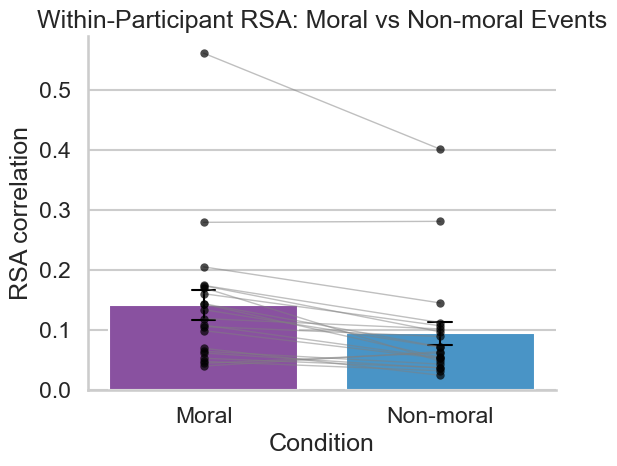

In [17]:

# Run split-half RSA using segments
rsa_moral_left  = run_within_participant_rsa_segments(left,  segments_moral)
rsa_moral_right = run_within_participant_rsa_segments(right, segments_moral)

rsa_nonmoral_left  = run_within_participant_rsa_segments(left,  segments_nonmoral)
rsa_nonmoral_right = run_within_participant_rsa_segments(right, segments_nonmoral)

# Combine hemispheres
rsa_moral_mean = (rsa_moral_left + rsa_moral_right)/2
rsa_nonmoral_mean = (rsa_nonmoral_left + rsa_nonmoral_right)/2
rsa_diff          = rsa_moral_mean - rsa_nonmoral_mean


# ================================================================
# Combine into one DataFrame
# ================================================================
rsa_df = pd.DataFrame({
    'participant': np.arange(len(rsa_moral_mean)),
    'rsa_moral_left': rsa_moral_left,
    'rsa_moral_right': rsa_moral_right,
    'rsa_moral_mean': rsa_moral_mean,
    'rsa_nonmoral_left': rsa_nonmoral_left,
    'rsa_nonmoral_right': rsa_nonmoral_right,
    'rsa_nonmoral_mean': rsa_nonmoral_mean,
    'rsa_diff': rsa_diff
})

# ================================================================
# === Group stats: paired t-test ===
# ================================================================
diffs = rsa_df['rsa_moral_mean'] - rsa_df['rsa_nonmoral_mean']
t_stat, p_val = ttest_rel(rsa_df['rsa_moral_mean'], rsa_df['rsa_nonmoral_mean'])

print("Paired t-test: t({}) = {:.3f}, p = {:.4f}".format(len(diffs)-1, t_stat, p_val))
print("Mean RSA moral:", rsa_df['rsa_moral_mean'].mean(), 
      "Mean RSA non-moral:", rsa_df['rsa_nonmoral_mean'].mean())

plt.figure(figsize=(6, 5))
sns.set(style='whitegrid', context='talk')

# Prepare for plotting
# ================================================================
plot_df = pd.melt(
    rsa_df,
    id_vars=['participant'],
    value_vars=['rsa_moral_mean', 'rsa_nonmoral_mean'],
    var_name='Condition',
    value_name='RSA'
)
plot_df['Condition'] = plot_df['Condition'].replace({
    'rsa_moral_mean': 'Moral',
    'rsa_nonmoral_mean': 'Non-moral'
})

ax = sns.barplot(
    data=plot_df,
    x='Condition', y='RSA', hue='Condition', legend=False,
    errorbar='se', capsize=0.1,
    err_kws={'color': 'black', 'linewidth': 1.5},
    palette=['#8E44AD', '#3498DB']
)

# Overlay participant dots + connecting lines
sns.stripplot(
    data=plot_df,
    x='Condition', y='RSA',
    color='black', size=6, jitter=False, alpha=0.7
)

# Connect participant dots
for pid in rsa_df['participant']:
    vals = plot_df.loc[plot_df['participant'] == pid, 'RSA'].values
    plt.plot([0, 1], vals, color='gray', alpha=0.5, linewidth=1)

ax.set_title('Within-Participant RSA: Moral vs Non-moral Events')
ax.set_ylabel('RSA correlation')
sns.despine()
plt.tight_layout()
plt.show()

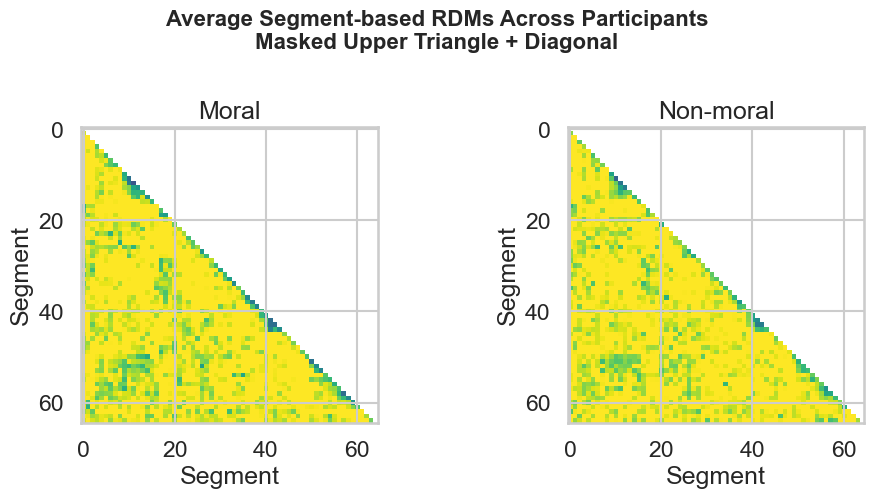

In [18]:
def average_segment_rdm(data_array, segments_df, demean=False):
    """
    Compute average RDM across participants using segment-based events.
    """
    segments_df = segments_df.dropna(subset=['startTR','endTR']).sort_values('startTR').reset_index(drop=True)
    segments_df['startTR'] = segments_df['startTR'].astype(int)
    segments_df['endTR']   = segments_df['endTR'].astype(int)
    segment_ids = segments_df.index.values

    # Odd/even split
    split1_ids = segment_ids[::2]
    split2_ids = segment_ids[1::2]
    n_events = min(len(split1_ids), len(split2_ids))
    split1_ids = split1_ids[:n_events]
    split2_ids = split2_ids[:n_events]

    n_participants = data_array.shape[2]
    rdms = []

    for p in range(n_participants):
        data = zscore(data_array[:, :, p], axis=1, ddof=1)

        split1_patterns, split2_patterns = [], []
        for eid in split1_ids:
            seg = segments_df.iloc[eid]
            split1_patterns.append(np.mean(data[:, seg['startTR']:seg['endTR']+1], axis=1))
        for eid in split2_ids:
            seg = segments_df.iloc[eid]
            split2_patterns.append(np.mean(data[:, seg['startTR']:seg['endTR']+1], axis=1))

        split1_patterns = np.column_stack(split1_patterns)
        split2_patterns = np.column_stack(split2_patterns)

        if demean:
            split1_patterns -= np.mean(split1_patterns, axis=1, keepdims=True)
            split2_patterns -= np.mean(split2_patterns, axis=1, keepdims=True)

        # Compute RDMs
        rdm1 = squareform(pdist(split1_patterns.T, metric='correlation'))
        rdm2 = squareform(pdist(split2_patterns.T, metric='correlation'))
        rdms.append((rdm1 + rdm2)/2)

    return np.mean(rdms, axis=0)


def mask_upper_diag(rdm):
    rdm_masked = rdm.copy()
    iu = np.triu_indices_from(rdm_masked)
    rdm_masked[iu] = np.nan
    return rdm_masked

# ----------------------------------------------------------
# Compute average RDMs
# ----------------------------------------------------------
rdm_moral_raw     = average_segment_rdm(left,  segments_moral, demean=False)
rdm_nonmoral_raw  = average_segment_rdm(left,  segments_nonmoral, demean=False)

# Mask diagonal + upper triangle
rdm_moral_raw_masked    = mask_upper_diag(rdm_moral_raw)
rdm_nonmoral_raw_masked = mask_upper_diag(rdm_nonmoral_raw)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, axes = plt.subplots(1,2, figsize=(10,5))

im0 = axes[0].imshow(rdm_moral_raw_masked, vmin=0.8, vmax=1, cmap='viridis')
axes[0].set_title("Moral")
im1 = axes[1].imshow(rdm_nonmoral_raw_masked, vmin=0.8, vmax=1, cmap='viridis')
axes[1].set_title("Non-moral")

for ax in axes.flatten():
    ax.set_xlabel("Segment")
    ax.set_ylabel("Segment")

#fig.colorbar(im0, ax=axes.ravel().tolist(), shrink=0.6, label="1 - Pearson r")
plt.suptitle("Average Segment-based RDMs Across Participants\nMasked Upper Triangle + Diagonal", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


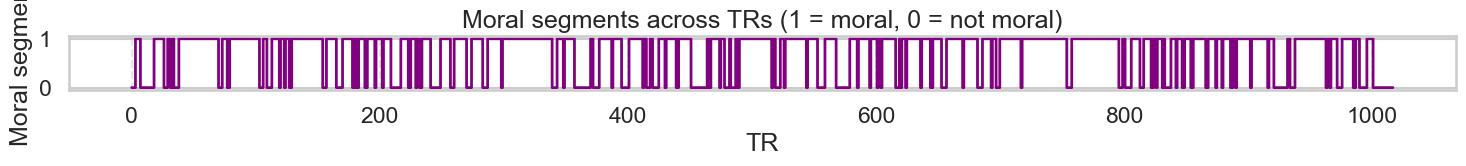

In [19]:
# ------------------------------------------------------
# ---- plot timeline of events/segments created --------
# ------------------------------------------------------

# Total number of TRs
n_trs = max(segments_moral['endTR'].max(), segments_nonmoral['endTR'].max()) + 1

# Initialize array
moral_trs = np.zeros(n_trs, dtype=int)

# Fill in 1 for TRs that belong to any moral segment
for _, seg in segments_moral.iterrows():
    moral_trs[seg['startTR']:seg['endTR']+1] = 1

# Plot
plt.figure(figsize=(15,2))
plt.plot(moral_trs, drawstyle='steps-post', color='purple', linewidth=2)
plt.xlabel("TR")
plt.ylabel("Moral segment")
plt.yticks([0,1])
plt.title("Moral segments across TRs (1 = moral, 0 = not moral)")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


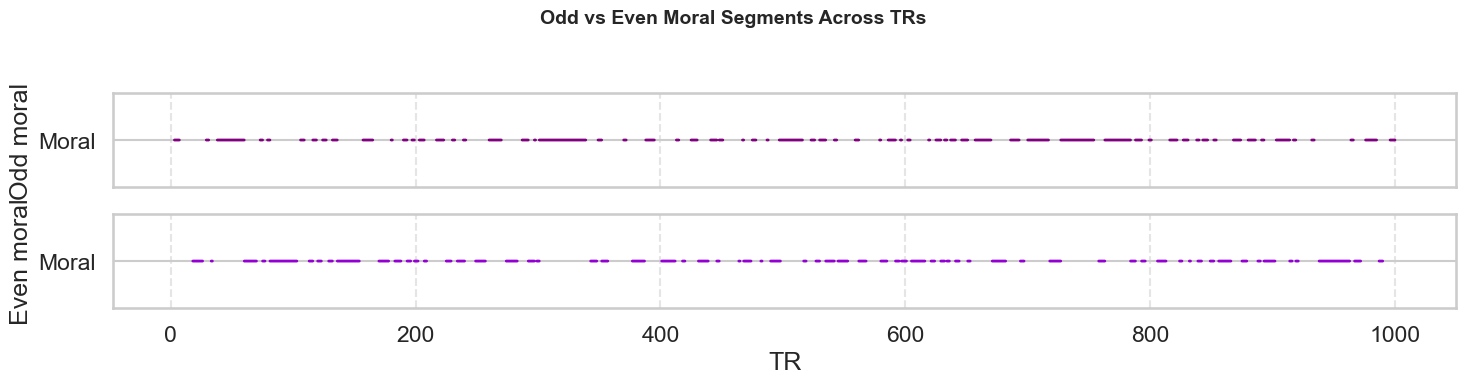

In [20]:
# ---------------------------------------------------------------------
# ---- plot timeline of odd vs even events/segments created for RSA --------
# ---------------------------------------------------------------------


# Total number of TRs
n_trs = segments_moral['endTR'].max() + 1

# Initialize arrays for odd/even moral events
moral_odd  = np.zeros(n_trs, dtype=float)
moral_even = np.zeros(n_trs, dtype=float)

# Odd/even split of moral segments
segment_ids = segments_moral.index.values
odd_ids  = segment_ids[::2]
even_ids = segment_ids[1::2]

# Fill 1 for TRs in moral segments
for eid in odd_ids:
    seg = segments_moral.iloc[eid]
    moral_odd[seg['startTR']:seg['endTR']+1] = 1

for eid in even_ids:
    seg = segments_moral.iloc[eid]
    moral_even[seg['startTR']:seg['endTR']+1] = 1

# Replace 0 with NaN to leave gaps blank
moral_odd_nan  = np.where(moral_odd==0, np.nan, moral_odd)
moral_even_nan = np.where(moral_even==0, np.nan, moral_even)

# Plot
fig, axes = plt.subplots(2,1, figsize=(15,4), sharex=True)

axes[0].plot(moral_odd_nan, drawstyle='steps-post', color='purple', linewidth=2)
axes[0].set_ylabel("Odd moral")
axes[0].set_yticks([1])
axes[0].set_yticklabels(['Moral'])
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

axes[1].plot(moral_even_nan, drawstyle='steps-post', color='darkviolet', linewidth=2)
axes[1].set_ylabel("Even moral")
axes[1].set_yticks([1])
axes[1].set_yticklabels(['Moral'])
axes[1].set_xlabel("TR")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Odd vs Even Moral Segments Across TRs", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


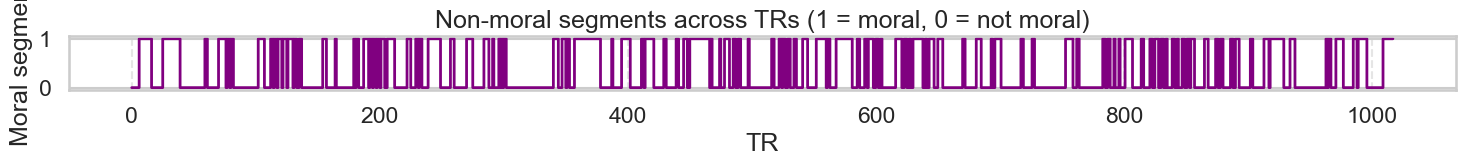

In [21]:
# ------------------------------------------------------
# ---- plot timeline of non-moral events/segments created --------
# ------------------------------------------------------

# Total number of TRs
n_trs = max(segments_moral['endTR'].max(), segments_nonmoral['endTR'].max()) + 1

# Initialize array
nonmoral_trs = np.zeros(n_trs, dtype=int)

# Fill in 1 for TRs that belong to any moral segment
for _, seg in segments_nonmoral.iterrows():
    nonmoral_trs[seg['startTR']:seg['endTR']+1] = 1

# Plot
plt.figure(figsize=(15,2))
plt.plot(nonmoral_trs, drawstyle='steps-post', color='purple', linewidth=2)
plt.xlabel("TR")
plt.ylabel("Moral segment")
plt.yticks([0,1])
plt.title("Non-moral segments across TRs (1 = moral, 0 = not moral)")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

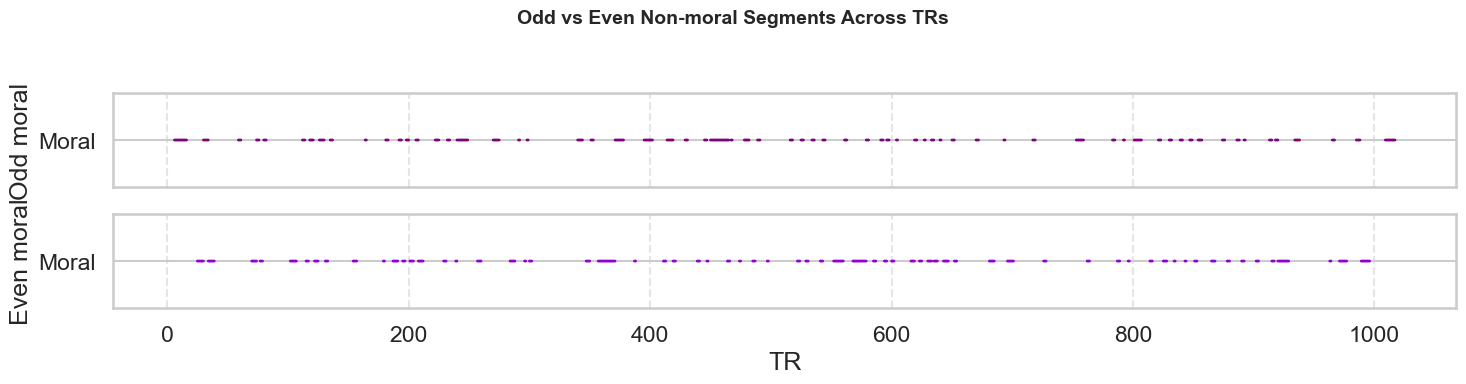

In [22]:
# ---------------------------------------------------------------------
# ---- plot timeline of odd vs even events/segments created for RSA --------
# ---------------------------------------------------------------------


# Total number of TRs
n_trs = segments_nonmoral['endTR'].max() + 1

# Initialize arrays for odd/even moral events
nonmoral_odd  = np.zeros(n_trs, dtype=float)
nonmoral_even = np.zeros(n_trs, dtype=float)

# Odd/even split of moral segments
segment_ids = segments_nonmoral.index.values
odd_ids  = segment_ids[::2]
even_ids = segment_ids[1::2]

# Fill 1 for TRs in moral segments
for eid in odd_ids:
    seg = segments_nonmoral.iloc[eid]
    nonmoral_odd[seg['startTR']:seg['endTR']+1] = 1

for eid in even_ids:
    seg = segments_nonmoral.iloc[eid]
    nonmoral_even[seg['startTR']:seg['endTR']+1] = 1

# Replace 0 with NaN to leave gaps blank
nonmoral_odd_nan  = np.where(nonmoral_odd==0, np.nan, nonmoral_odd)
nonmoral_even_nan = np.where(nonmoral_even==0, np.nan, nonmoral_even)

# Plot
fig, axes = plt.subplots(2,1, figsize=(15,4), sharex=True)

axes[0].plot(nonmoral_odd_nan, drawstyle='steps-post', color='purple', linewidth=2)
axes[0].set_ylabel("Odd moral")
axes[0].set_yticks([1])
axes[0].set_yticklabels(['Moral'])
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)


axes[1].plot(nonmoral_even_nan, drawstyle='steps-post', color='darkviolet', linewidth=2)
axes[1].set_ylabel("Even moral")
axes[1].set_yticks([1])
axes[1].set_yticklabels(['Moral'])
axes[1].set_xlabel("TR")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Odd vs Even Non-moral Segments Across TRs", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
